### Today task is to compare the performance of:
	•	A CNN trained from scratch
	•	A model using Transfer Learning (MobileNetV2)

for classifying flower images.



#### After this lab, students will be able to:
	•	Build a CNN model from scratch
	•	Apply transfer learning using a pre-trained network
	•	Compare training accuracy, Precision and Recall
	•	Analyze learning curves
	•	Understand why transfer learning is effective

#### 🧑‍🎓 Student Details

| Field                | Information                |
|---------------------|----------------------------|
| 👨‍🎓 **Name**            | Nilanjana Jamindar     |
| 🆔 **USN**              | 1RUB25CSE0013           |
| **Programme**   | M.Tech (CSE)             |
| **School**  | Computer Science and Engineering |


### Transfer Learning reuses knowledge learned from large datasets (e.g., ImageNet) to solve new problems efficiently.

#### Key idea:
	•	Early CNN layers learn generic features (edges, textures)
	•	Later layers learn task-specific features
	•	We reuse earlier layers and train only new layers


**Task 01:** Load the important libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import tensorflow as tf
import keras
from keras import layers, models
import cv2

**Task 02:** Load Dataset

We use the TensorFlow Flower dataset containing 5 classes.

In [2]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = keras.utils.get_file("flower_photos", origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_dir)

print("data_dir =", data_dir)

data_dir = /root/.keras/datasets/flower_photos


**Task 03:** Data Exploration

In [3]:
if (data_dir / "flower_photos").exists():
    data_dir = data_dir / "flower_photos"
    print("Fixed data_dir =", data_dir)

Fixed data_dir = /root/.keras/datasets/flower_photos/flower_photos


In [4]:
print("Total jpg:", len(list(data_dir.glob("*/*.jpg"))))
print("Class counts:")
for cls in ["roses","daisy","dandelion","sunflowers","tulips"]:
    print(cls, len(list(data_dir.glob(f"{cls}/*.jpg"))))

Total jpg: 3670
Class counts:
roses 641
daisy 633
dandelion 898
sunflowers 699
tulips 799


In [5]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

**Task 04:** — Create Training and Validation Sets

In [6]:
IMG_SIZE = (224, 224)      # Fill
BATCH_SIZE = 32            # Fill
SEED = 123

train_ds = keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split = 0.25,
    subset = "training",
    seed = SEED,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

val_ds = keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split = 0.25,
    subset = "validation",
    seed = SEED,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)

Found 3670 files belonging to 5 classes.
Using 2753 files for training.
Found 3670 files belonging to 5 classes.
Using 917 files for validation.
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


**Task 05:** Visualizing Simple Images for Pre-check

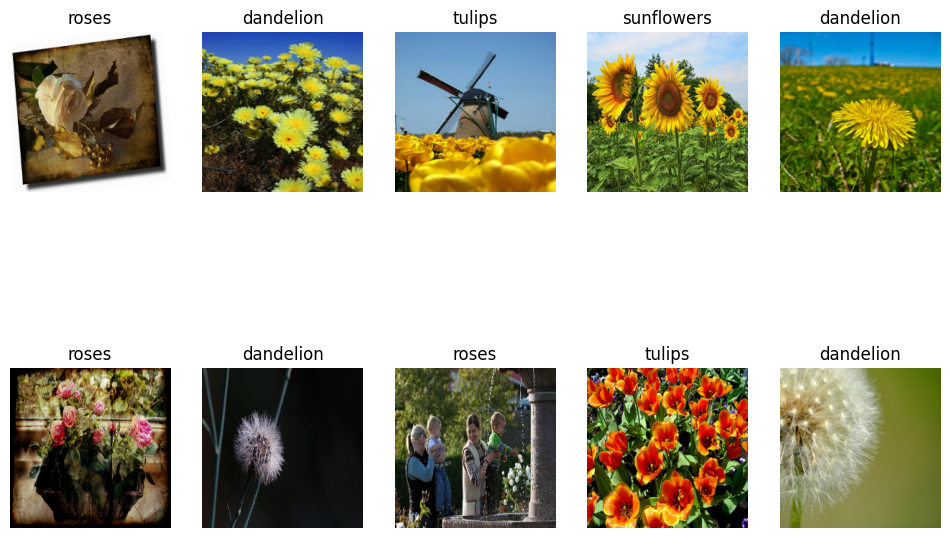

In [7]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 8))
for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[int(labels[i])])
    plt.axis("off")
plt.show()

**Task 06:** — Optimize Dataset Pipeline

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

normalizer = layers.Rescaling(1./255)

**Task 07** -- Implement CNN without Transfer Learning

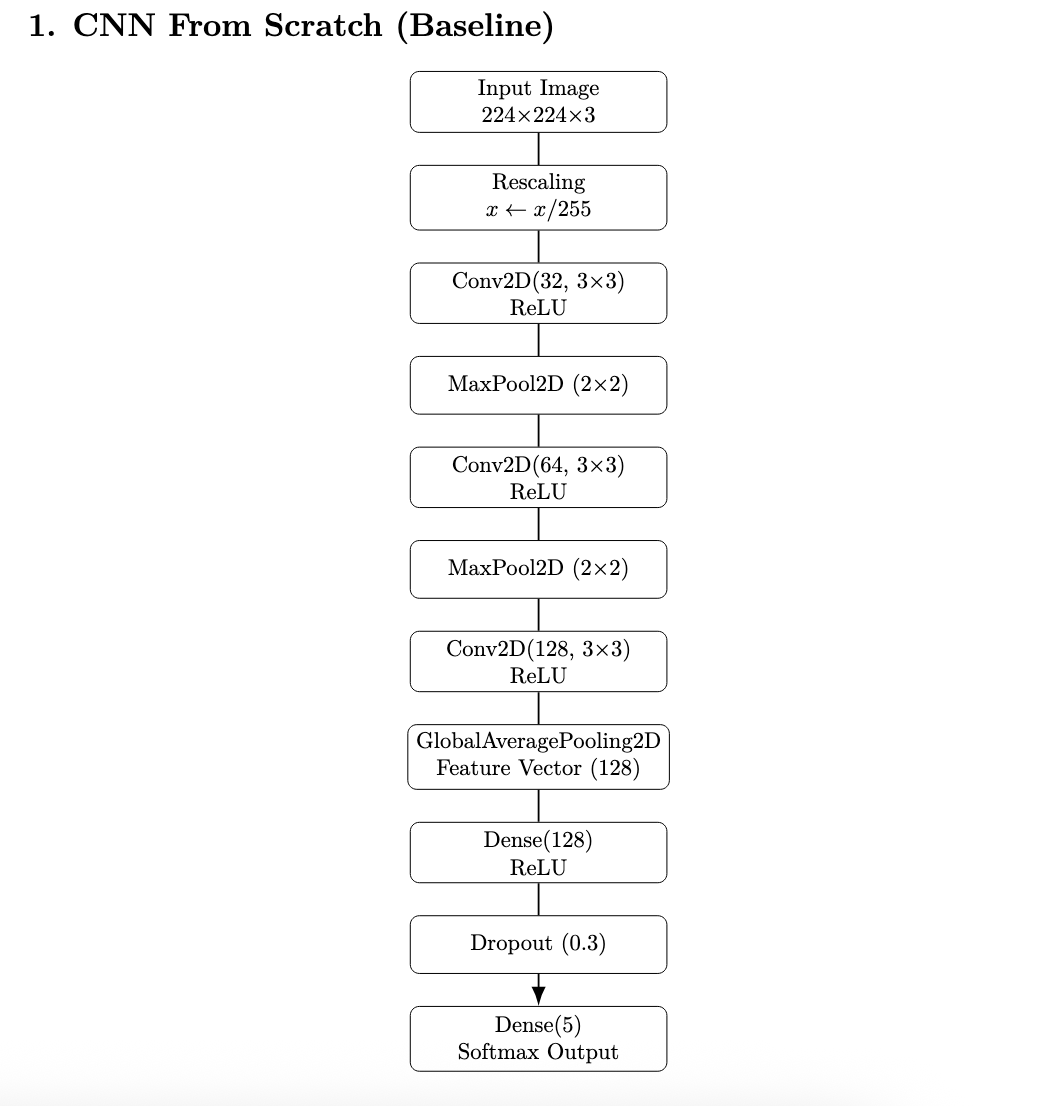

In [9]:
baseline_model = keras.Sequential([

    layers.Input(shape = IMG_SIZE + (3,)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,405 (431.27 KB)

 Trainable params: 110,405 (431.27 KB)

 Non-trainable params: 0 (0.00 B)

**Task 08:** Train the baseline model for study

In [10]:
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 23s 125ms/step - accuracy: 0.3295 - loss: 1.4493 - val_accuracy: 0.4231 - val_loss: 1.2918
Epoch 2/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - accuracy: 0.4373 - loss: 1.2467 - val_accuracy: 0.4602 - val_loss: 1.2499
Epoch 3/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.4693 - loss: 1.2118 - val_accuracy: 0.5354 - val_loss: 1.1522
Epoch 4/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.5104 - loss: 1.1486 - val_accuracy: 0.5224 - val_loss: 1.1238
Epoch 5/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.5390 - loss: 1.1237 - val_accuracy: 0.5474 - val_loss: 1.0862
Epoch 6/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.5514 - loss: 1.0804 - val_accuracy: 0.5278 - val_loss: 1.0917
Epoch 7/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.5823 - loss: 1.0538 - val_accuracy: 0.5736 - val_loss: 1.0656
Epoch 8/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.5801 - loss: 1.0438 - val_accuracy: 0.5714 

Task 09: Implement the CNN with Transfer Learning using MobileVnet Model [ Lightweight ]

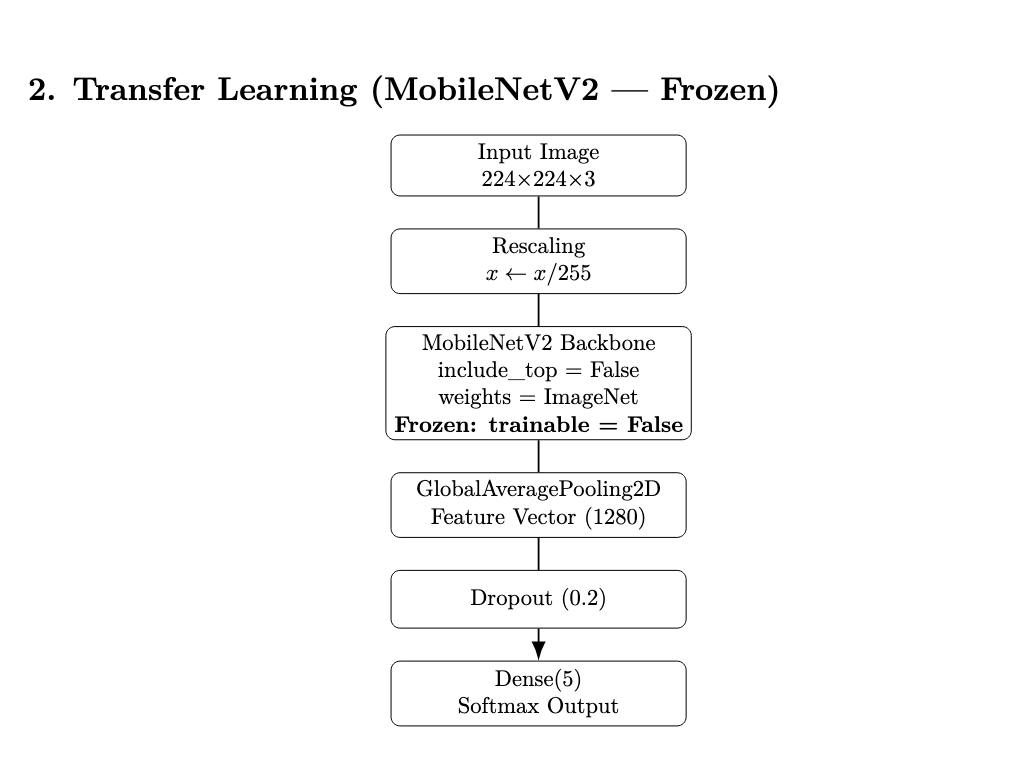

In [11]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape = IMG_SIZE + (3,),
    include_top = False,    # Fill
    weights = 'imagenet'         # Fill
)

base_model.trainable = False  # Freeze or not?

tl_model = keras.Sequential([
    layers.Input(shape = IMG_SIZE + (3,)),
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),   # Fill
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation="softmax")
])

In [12]:
tl_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

tl_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Task 10:** Train the tranfer learning model

In [13]:
history_tl = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 50s 358ms/step - accuracy: 0.6753 - loss: 0.8454 - val_accuracy: 0.8255 - val_loss: 0.5001
Epoch 2/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.8256 - loss: 0.4693 - val_accuracy: 0.8451 - val_loss: 0.4386
Epoch 3/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.8696 - loss: 0.3806 - val_accuracy: 0.8680 - val_loss: 0.3798
Epoch 4/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8885 - loss: 0.3241 - val_accuracy: 0.8779 - val_loss: 0.3624
Epoch 5/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8997 - loss: 0.2947 - val_accuracy: 0.8866 - val_loss: 0.3477
Epoch 6/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9139 - loss: 0.2606 - val_accuracy: 0.8899 - val_loss: 0.3345
Epoch 7/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9230 - loss: 0.2432 - val_accuracy: 0.8855 - val_loss: 0.3283
Epoch 8/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9310 - loss: 0.2227 - val_accuracy: 0.8953 -

#Compare the Learning curves of both

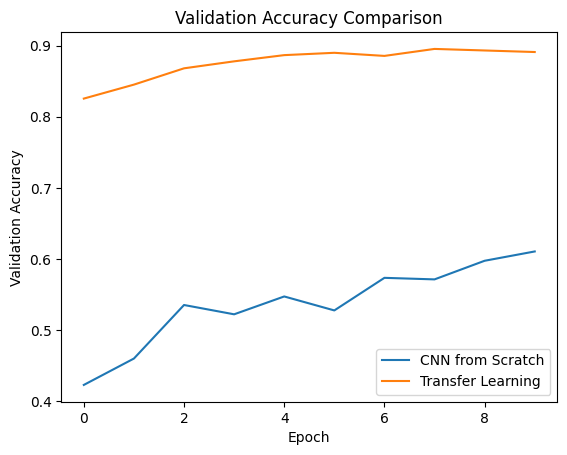

In [14]:
plt.figure()

plt.plot(history_baseline.history["val_accuracy"],
         label="CNN from Scratch")

plt.plot(history_tl.history["val_accuracy"],
         label="Transfer Learning")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()

plt.show()

### Performance Comparison Table

In [15]:
import pandas as pd

summary = pd.DataFrame([
    {
        "Model": "CNN from Scratch",
        "Epochs": len(history_baseline.history["val_accuracy"]),
        "Total Params": baseline_model.count_params(),
        "Best Val Acc": max(history_baseline.history["val_accuracy"])
    },
    {
        "Model": "Transfer Learning",
        "Epochs": len(history_tl.history["val_accuracy"]),
        "Total Params": tl_model.count_params(),
        "Best Val Acc": max(history_tl.history["val_accuracy"])
    }
])

summary

,Model,Epochs,Total Params,Best Val Acc
0,CNN from Scratch,10,110405,0.610687
1,Transfer Learning,10,2264389,0.895311


## Answer the following questions:

1. Which model converges faster?
2. Which model shows higher validation accuracy?
3. Does CNN from scratch show signs of overfitting? Explain.
4. Why does TL have many parameters but few trainable ones?
5. Why does freezing layers reduce training time?
6. Which model requires more data to train effectively?

## Prediction on Validation Data

In [16]:
import numpy as np

def get_true_and_pred(model, dataset):
    y_true = []
    y_pred = []

    for x_batch, y_batch in dataset:
        probs = model.predict(x_batch, verbose=0)     # (batch, num_classes)
        preds = np.argmax(probs, axis=1)             # predicted class index

        y_true.extend(y_batch.numpy())
        y_pred.extend(preds)

    return np.array(y_true), np.array(y_pred)

y_true_base, y_pred_base = get_true_and_pred(baseline_model, val_ds)
y_true_tl,   y_pred_tl   = get_true_and_pred(tl_model, val_ds)

In [17]:
acc_base = (y_true_base == y_pred_base).mean()
acc_tl   = (y_true_tl == y_pred_tl).mean()

print("Baseline CNN Test Accuracy:", round(acc_base, 4))
print("Transfer Learning Test Accuracy:", round(acc_tl, 4))

Baseline CNN Test Accuracy: 0.6107
Transfer Learning Test Accuracy: 0.8909


<Figure size 640x480 with 0 Axes>

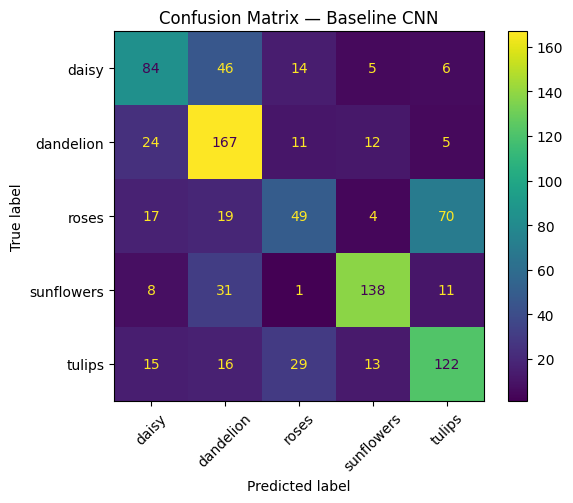

<Figure size 640x480 with 0 Axes>

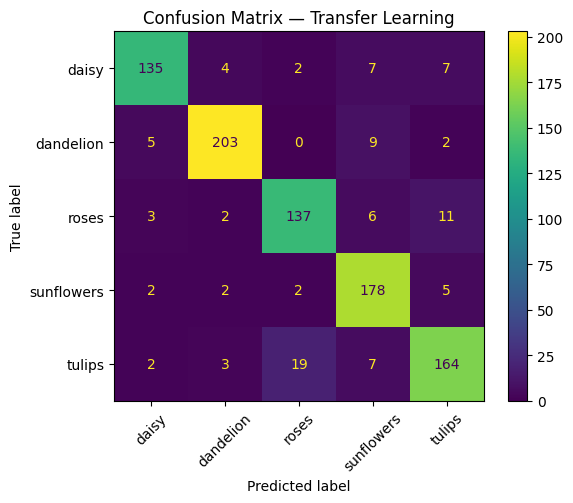

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_base = confusion_matrix(y_true_base, y_pred_base)
cm_tl   = confusion_matrix(y_true_tl, y_pred_tl)

plt.figure()
ConfusionMatrixDisplay(cm_base, display_labels=class_names).plot(xticks_rotation=45)
plt.title("Confusion Matrix — Baseline CNN")
plt.show()

plt.figure()
ConfusionMatrixDisplay(cm_tl, display_labels=class_names).plot(xticks_rotation=45)
plt.title("Confusion Matrix — Transfer Learning")
plt.show()

## Answer the following questions:

1. Which classes are most confused by CNN from scratch?
2. Which class shows highest accuracy in TL model?
3. Why might “roses” be harder to classify than “sunflowers”?

In [19]:
from sklearn.metrics import classification_report

print("=== Baseline CNN Report ===")
print(classification_report(y_true_base, y_pred_base, target_names=class_names))

print("=== Transfer Learning Report ===")
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))

=== Baseline CNN Report ===
              precision    recall  f1-score   support

       daisy       0.57      0.54      0.55       155
   dandelion       0.60      0.76      0.67       219
       roses       0.47      0.31      0.37       159
  sunflowers       0.80      0.73      0.76       189
      tulips       0.57      0.63      0.60       195

    accuracy                           0.61       917
   macro avg       0.60      0.59      0.59       917
weighted avg       0.61      0.61      0.60       917

=== Transfer Learning Report ===
              precision    recall  f1-score   support

       daisy       0.92      0.87      0.89       155
   dandelion       0.95      0.93      0.94       219
       roses       0.86      0.86      0.86       159
  sunflowers       0.86      0.94      0.90       189
      tulips       0.87      0.84      0.85       195

    accuracy                           0.89       917
   macro avg       0.89      0.89      0.89       917
weighted avg    

## Answer the following questions:

1.	Which class has lowest F1-score in baseline CNN?
2.	How much did overall accuracy improve using TL?
3.	Why does precision differ from recall?

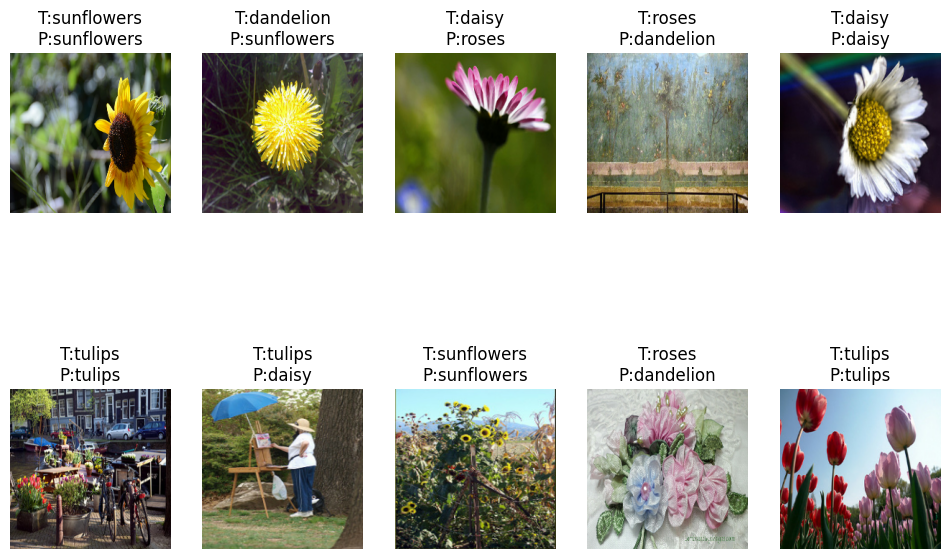

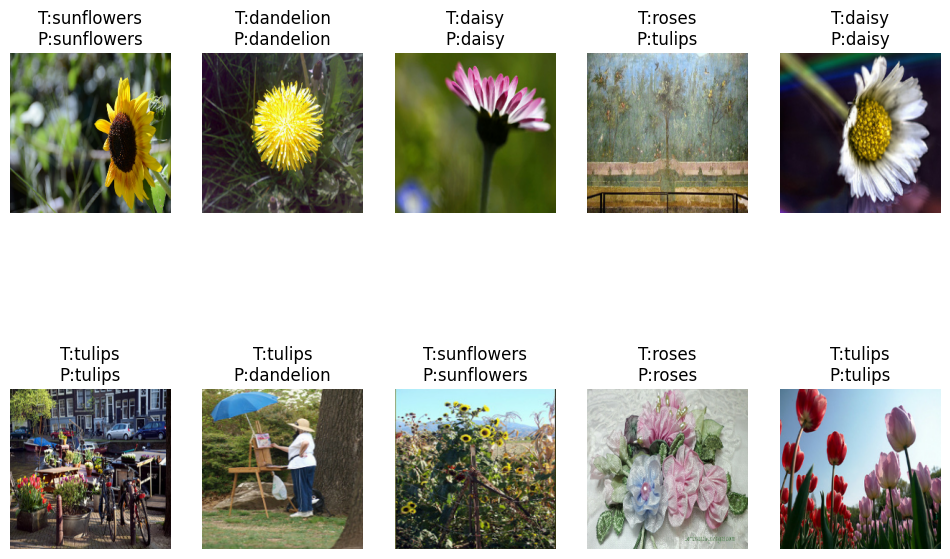

In [20]:
import matplotlib.pyplot as plt

def show_prediction_grid(model, dataset, class_names, n=10):
    images, labels = next(iter(dataset))
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    plt.figure(figsize=(12,8))
    for i in range(n):
        ax = plt.subplot(2, 5, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        t = class_names[int(labels[i])]
        p = class_names[int(preds[i])]
        plt.title(f"T:{t}\nP:{p}")
        plt.axis("off")
    plt.show()

show_prediction_grid(baseline_model, val_ds, class_names, n=10)
show_prediction_grid(tl_model, val_ds, class_names, n=10)

Questions:

	1.	Why does TL have many parameters but few trainable ones?
	2.	Why does freezing layers reduce training time?
	3.	Which model requires more data to train effectively?

## Test on new data

In [21]:
from google.colab import files
uploaded = files.upload()

Saving img03.jpg to img03.jpg


In [22]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np

IMG_SIZE = (224, 224)

def preprocess_image(image_path):
    img = load_img(image_path, target_size=IMG_SIZE)
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    return img_array

In [23]:
test_image = preprocess_image("img03.jpg")

predictions = tl_model.predict(test_image)

predicted_class = np.argmax(predictions[0])
confidence = np.max(predictions[0])

print("Predicted Flower:", class_names[predicted_class])
print("Confidence:", round(confidence*100, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted Flower: roses
Confidence: 99.21 %


**Final Task for Students:** Fine-Tuning Task - Unfreeze last layers of MobileNetV2 and retrain for 3 epochs.

Interpret:

	•	Accuracy change
	•	Overfitting risk

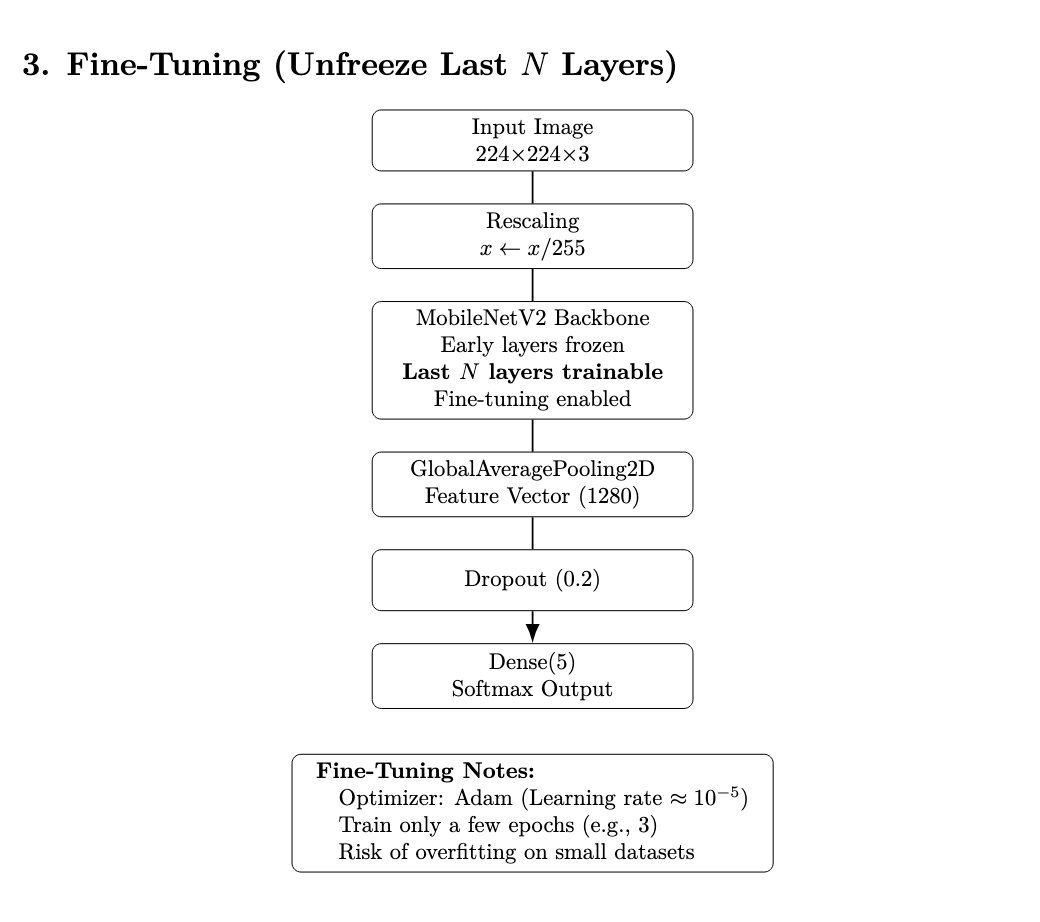

In [24]:
# Unfreeze the base model
base_model.trainable = True

# Refreeze all layers EXCEPT the last N (e.g., last 20 layers)
# MobileNetV2 has 154 layers total.
fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile with a MUCH smaller learning rate
# High learning rates can wreck the pre-trained weights
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Retrain for 3 epochs
fine_tune_epochs = 3
total_epochs = 10 + fine_tune_epochs # 10 from previous run + 3 new

history_fine = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history_tl.epoch[-1] # Starts training from where it left off
)

Epoch 10/13
87/87 ━━━━━━━━━━━━━━━━━━━━ 44s 246ms/step - accuracy: 0.8249 - loss: 0.4814 - val_accuracy: 0.8931 - val_loss: 0.3136
Epoch 11/13
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.8965 - loss: 0.3017 - val_accuracy: 0.8975 - val_loss: 0.3065
Epoch 12/13
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.9335 - loss: 0.2218 - val_accuracy: 0.9062 - val_loss: 0.3018
Epoch 13/13
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.9495 - loss: 0.1725 - val_accuracy: 0.9073 - val_loss: 0.2996


In [25]:
# Combine the histories
acc = history_tl.history['accuracy'] + history_fine.history['accuracy']
val_acc = history_tl.history['val_accuracy'] + history_fine.history['val_accuracy']

# Print the numerical delta
initial_val_acc = history_tl.history['val_accuracy'][-1]
final_val_acc = history_fine.history['val_accuracy'][-1]
accuracy_change = final_val_acc - initial_val_acc

print(f"--- Accuracy Analysis ---")
print(f"Validation Acc after Feature Extraction: {initial_val_acc:.4f}")
print(f"Validation Acc after Fine-Tuning:        {final_val_acc:.4f}")
print(f"Total Change:                            {accuracy_change:+.4f}")

--- Accuracy Analysis ---
Validation Acc after Feature Extraction: 0.8909
Validation Acc after Fine-Tuning:        0.9073
Total Change:                            +0.0164


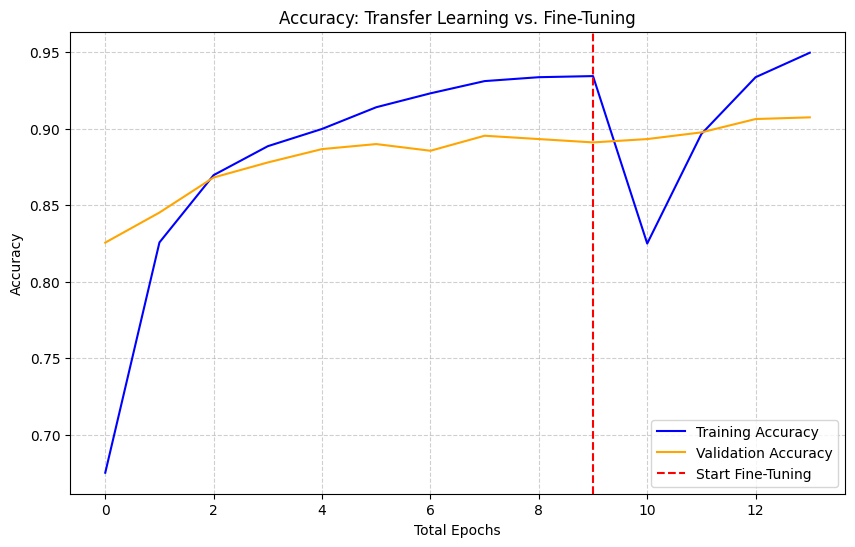

In [26]:
plt.figure(figsize=(10, 6))

# Plot Accuracy
plt.plot(acc, label='Training Accuracy', color='blue')
plt.plot(val_acc, label='Validation Accuracy', color='orange')

# Draw a vertical line to show where Fine-Tuning started
plt.axvline(x=len(history_tl.history['accuracy'])-1, color='red', linestyle='--', label='Start Fine-Tuning')

plt.title('Accuracy: Transfer Learning vs. Fine-Tuning')
plt.xlabel('Total Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()